In [1]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow.keras.layers as L
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
import tensorflow.keras.regularizers as R
from tensorflow.keras.optimizers import Adam

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Paths

In [3]:
DRIVE_EXT = "/content/drive/My Drive"
IMAGE_DIR = f"{DRIVE_EXT}/LabelStudioToMask_FINAL/images"
MASK_DIR = f"{DRIVE_EXT}/LabelStudioToMask_FINAL/masks"
sample_img = f"{DRIVE_EXT}/LabelStudioToMask_FINAL/images/RVG_1.png"
sample_mask = f"{DRIVE_EXT}/LabelStudioToMask_FINAL/masks/RVG_1_mask.png"

## Loading the images

In [4]:
TARGET_SIZE = (790, 1100)
def load_image(image_path):
    img_obj = tf.io.read_file(image_path)
    image = tf.io.decode_png(img_obj, channels=1)
    image = tf.image.resize(image, TARGET_SIZE, method='bilinear')
    image = tf.pad(image, [[5,5],[2,2],[0,0]])   # pad H,W
    image = tf.cast(image, tf.float32) / 255.0 # Normalization
    return image

s = load_image(sample_img)
print("Sample image shape: ", s.shape)

Sample image shape:  (800, 1104, 1)


In [5]:
def load_mask(mask_path):
    """We have 4 classes."""
    mask = tf.io.decode_png(tf.io.read_file(mask_path), channels=1)
    mask = tf.image.resize(mask, TARGET_SIZE, method='nearest')
    mask = tf.pad(mask, [[5,5],[2,2],[0,0]])   # pad H,W
    mask = tf.cast(mask, tf.int32)
    mask = mask // 85   # 0→0, 85→1, 170→2, 255→3
    return mask

s1 = load_mask(sample_mask)
print("Size of list: ", len(s1), "Shape of mask : ", s1[0].shape)
# print("Sample mask shape: ", s1.shape)

Size of list:  800 Shape of mask :  (1104, 1)


In [9]:
def load_pair(image_path):
    """Extract name: RVG_1.png → RVG_1_mask.png"""
    filename = tf.strings.split(image_path, '/')[-1]   # RVG_1.png
    noext = tf.strings.regex_replace(filename, ".png", "")
    mask_name = noext + "_mask.png"
    mask_path = tf.strings.join([MASK_DIR, "/", mask_name])

    return load_image(image_path), load_mask(mask_path)

sample_pair = load_pair(sample_img)
print("Shapes of sample image: ", sample_pair[0].shape," And sample mask", sample_pair[1].shape)

Shapes of sample image:  (800, 1104, 1)  And sample mask (800, 1104, 1)


In [11]:
image_files = sorted([IMAGE_DIR + "/" + f for f in os.listdir(IMAGE_DIR)])
ds = tf.data.Dataset.from_tensor_slices(image_files)
ds = ds.map(load_pair, num_parallel_calls=4)

#Splits
dataset_size = len(image_files)
train_size = int(0.7 * dataset_size)      # 61 for 88 images
val_size   = int(0.1 * dataset_size)     # 13 for 88 images
test_size  = dataset_size - train_size - val_size   # 14 for 88 images

BATCH_SIZE = 4

train_data = ds.take(train_size).batch(BATCH_SIZE)
val_data   = ds.skip(train_size).take(val_size).batch(BATCH_SIZE)
test_data  = ds.skip(train_size + val_size).take(test_size).batch(BATCH_SIZE)

print("Size of train data : ", train_data.cardinality().numpy())
print("Size of validation data : ", val_data.cardinality().numpy())
print("Size of test data : ", test_data.cardinality().numpy())
print("Total data size : ", train_data.cardinality().numpy() + val_data.cardinality().numpy() + test_data.cardinality().numpy())

Size of train data :  16
Size of validation data :  2
Size of test data :  5
Total data size :  23


## Defining the all blocks of the attention U-net block

In [12]:
def conv_block(inputs, num_filters):
    """This is the convolution block. There are two L in here. Takes input and number of filters as arguments"""
    x = L.Conv2D(num_filters, 3, padding="same")(inputs)
    x = L.BatchNormalization()(x)
    x = L.ReLU()(x)

    x = L.Conv2D(num_filters, 3, padding="same")(x)
    x = L.BatchNormalization()(x)
    x = L.ReLU()(x)

    return x

In [13]:
def attention_gate(x, g, filters):
    """ Attention gate to focus on important features."""
    theta_x = L.Conv2D(filters, 1)(x)
    phi_g   = L.Conv2D(filters, 1)(g)

    add = L.Add()([theta_x, phi_g])
    act = L.ReLU()(add)

    psi = L.Conv2D(1, 1, activation="sigmoid")(act)
    out = L.Multiply()([x, psi])   # attention-filtered skip

    return out


# Defining custom loss functions

In [15]:
def dice_loss(y_true, y_pred):
    y_true = tf.squeeze(y_true, axis=-1)

    y_true = tf.one_hot(tf.cast(y_true, tf.int32), 4)
    y_pred = tf.nn.softmax(y_pred)

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true + y_pred)

    return 1 - (2. * intersection + 1) / (union + 1)


def iou_metric(y_true, y_pred):
    y_true = tf.squeeze(y_true, axis=-1)

    y_true = tf.one_hot(tf.cast(y_true, tf.int32), 4)
    y_pred = tf.nn.softmax(y_pred)

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true + y_pred - (y_true * y_pred))

    return (intersection + 1) / (union + 1)

## Callbacks

In [16]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.8,
    patience=30,
    min_lr=1e-6,
    verbose=1
)

callbacks = [reduce_lr]


# Defining the entirety of the U-net ++

![UNet++ Architecture](https://media.geeksforgeeks.org/wp-content/uploads/20230628132335/UNET.webp)


In [17]:
def attn_UNET_PP(input_shape, n_classes=4, init_filters=32): # Original init is 126 filters.
    inputs = L.Input(input_shape)

    # Number of filters
    f1 = init_filters
    f2 = f1 * 2
    f3 = f2 * 2
    f4 = f3 * 2
    f5 = f4 * 2

    # Encoder side
    x0_0 = conv_block(inputs, f1)
    p1   = L.MaxPool2D()(x0_0)

    x1_0 = conv_block(p1, f2)
    p2   = L.MaxPool2D()(x1_0)

    x2_0 = conv_block(p2, f3)
    p3   = L.MaxPool2D()(x2_0)

    x3_0 = conv_block(p3, f4)
    p4   = L.MaxPool2D()(x3_0)

    x4_0 = conv_block(p4, f5)

    # Decoder side + skip connections

    # Level 3
    g3 = L.UpSampling2D()(x4_0)
    a3 = attention_gate(x3_0, g3, f4)
    x3_1 = conv_block(L.Concatenate()([g3, a3]), f4)

    # Level 2
    g2 = L.UpSampling2D()(x3_1)
    a2_0 = attention_gate(x2_0, g2, f3)
    a2_1 = attention_gate(x2_0, g2, f3)

    x2_1 = conv_block(L.Concatenate()([g2, a2_0]), f3)
    x2_2 = conv_block(L.Concatenate()([x2_1, a2_1]), f3)

    # Level 1
    g1 = L.UpSampling2D()(x2_2)
    a1_0 = attention_gate(x1_0, g1, f2)
    a1_1 = attention_gate(x1_0, g1, f2)

    x1_1 = conv_block(L.Concatenate()([g1, a1_0]), f2)
    x1_2 = conv_block(L.Concatenate()([x1_1, a1_1]), f2)

    # Level 0
    g0 = L.UpSampling2D()(x1_2)
    a0_0 = attention_gate(x0_0, g0, f1)
    a0_1 = attention_gate(x0_0, g0, f1)

    x0_1 = conv_block(L.Concatenate()([g0, a0_0]), f1)
    x0_2 = conv_block(L.Concatenate()([x0_1, a0_1]), f1)

    # Deep supervision
    out1 = L.Conv2D(n_classes, 1, activation="softmax", name="ds1")(x0_1)

    out2 = L.Conv2D(n_classes, 1, activation="softmax", name="ds2")(x0_2)

    up3 = L.UpSampling2D(size=(2, 2), interpolation="bilinear")(x1_2)
    out3 = L.Conv2D(n_classes, 1, activation="softmax", name="ds3")(up3)

    up4 = L.UpSampling2D(size=(4, 4), interpolation="bilinear")(x2_2)
    out4 = L.Conv2D(n_classes, 1, activation="softmax", name="ds4")(up4)

    model = Model(inputs, [out1, out2, out3, out4])

    return model


In [18]:
input_shape = (None, None, 1)
model = attn_UNET_PP(input_shape, init_filters=16)
# loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

model.compile(
    optimizer="adam",
    loss={
        "ds1": "sparse_categorical_crossentropy",
        "ds2": "sparse_categorical_crossentropy",
        "ds3": "sparse_categorical_crossentropy",
        "ds4": "sparse_categorical_crossentropy"
    },
    metrics=[
        ["accuracy", iou_metric, dice_loss],
        ["accuracy", iou_metric, dice_loss],
        ["accuracy", iou_metric, dice_loss],
        ["accuracy", iou_metric, dice_loss],
    ]
)

print("model.output_shape:", model.output_shape)

model.summary()

model.output_shape: [(None, None, None, 4), (None, None, None, 4), (None, None, None, 4), (None, None, None, 4)]


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, None,      │        160 │ input_layer[0][0] │
│                     │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, None,      │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, None,      │          0 │ batch_normalizat… │
│                     │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, None,      │      2,320 │ re_lu[0][0]       │
│                     │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, None,      │          0 │ batch_normalizat… │
│                     │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, None,      │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, None,      │      4,640 │ max_pooling2d[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, None,      │          0 │ batch_normalizat… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, None,      │      9,248 │ re_lu_2[0][0]     │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, None,      │          0 │ batch_normalizat… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, None,      │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, None,      │     18,496 │ max_pooling2d_1[… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        256 │ conv2d_4[0][0]  

 Total params: 2,197,479 (8.38 MB)

 Trainable params: 2,194,087 (8.37 MB)

 Non-trainable params: 3,392 (13.25 KB)

## Model training

In [19]:
def duplicate_mask(image, mask):
    return image, {
        "ds1": mask,
        "ds2": mask,
        "ds3": mask,
        "ds4": mask
    }

transformed_train_data = train_data.map(duplicate_mask)
transformed_val_data   = val_data.map(duplicate_mask)
transformed_test_data  = test_data.map(duplicate_mask)

In [20]:
history = model.fit(
    transformed_train_data,
    validation_data = transformed_val_data,
    epochs=50,
    callbacks=callbacks
)


Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 193s 5s/step - ds1_accuracy: 0.5321 - ds1_dice_loss: 0.7111 - ds1_iou_metric: 0.1689 - ds1_loss: 1.1250 - ds2_accuracy: 0.4587 - ds2_dice_loss: 0.7237 - ds2_iou_metric: 0.1604 - ds2_loss: 1.2435 - ds3_accuracy: 0.4349 - ds3_dice_loss: 0.7268 - ds3_iou_metric: 0.1584 - ds3_loss: 1.2729 - ds4_accuracy: 0.4555 - ds4_dice_loss: 0.7199 - ds4_iou_metric: 0.1631 - ds4_loss: 1.2413 - loss: 4.8834 - val_ds1_accuracy: 0.2845 - val_ds1_dice_loss: 0.7493 - val_ds1_iou_metric: 0.1433 - val_ds1_loss: 1.3753 - val_ds2_accuracy: 0.2801 - val_ds2_dice_loss: 0.7469 - val_ds2_iou_metric: 0.1449 - val_ds2_loss: 1.3400 - val_ds3_accuracy: 0.2801 - val_ds3_dice_loss: 0.7494 - val_ds3_iou_metric: 0.1432 - val_ds3_loss: 1.3784 - val_ds4_accuracy: 0.4474 - val_ds4_dice_loss: 0.7462 - val_ds4_iou_metric: 0.1453 - val_ds4_loss: 1.3290 - val_loss: 5.4227 - learning_rate: 0.0010
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - ds1_accuracy: 0.6306 - ds1_dice_loss: 0.6899 - 

KeyboardInterrupt: 

## Plotting loss curves

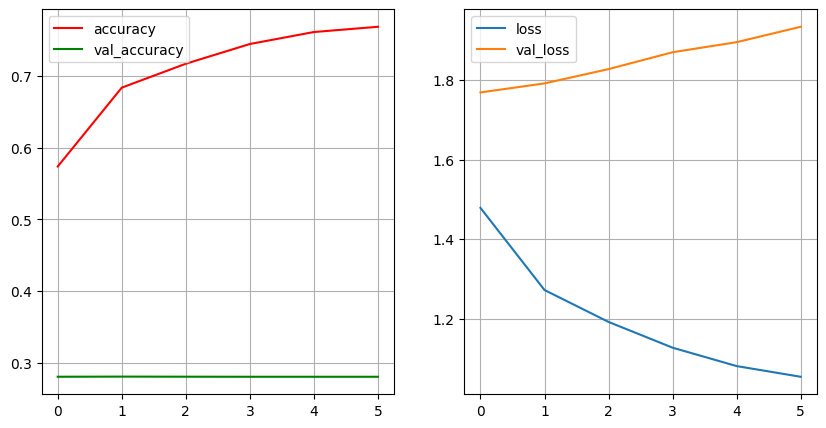

In [ ]:
his = history.history

plt.figure(figsize=(22, 12))

# -------------------------------------------------------
# Plot 1: Metrics for ds1
# -------------------------------------------------------
plt.subplot(2, 3, 1)
plt.plot(his["ds1_loss"], label="ds1_loss")
plt.plot(his["ds1_accuracy"], label="ds1_accuracy")
plt.plot(his["ds1_dice_loss"], label="ds1_dice_loss")
plt.plot(his["ds1_iou_metric"], label="ds1_iou_metric")
plt.title("Metrics for ds1")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid()

# -------------------------------------------------------
# Plot 2: Metrics for ds2
# -------------------------------------------------------
plt.subplot(2, 3, 2)
plt.plot(his["ds2_loss"], label="ds2_loss")
plt.plot(his["ds2_accuracy"], label="ds2_accuracy")
plt.plot(his["ds2_dice_loss"], label="ds2_dice_loss")
plt.plot(his["ds2_iou_metric"], label="ds2_iou_metric")
plt.title("Metrics for ds2")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid()

# -------------------------------------------------------
# Plot 3: Metrics for ds3
# -------------------------------------------------------
plt.subplot(2, 3, 3)
plt.plot(his["ds3_loss"], label="ds3_loss")
plt.plot(his["ds3_accuracy"], label="ds3_accuracy")
plt.plot(his["ds3_dice_loss"], label="ds3_dice_loss")
plt.plot(his["ds3_iou_metric"], label="ds3_iou_metric")
plt.title("Metrics for ds3")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid()

# -------------------------------------------------------
# Plot 4: Metrics for ds4
# -------------------------------------------------------
plt.subplot(2, 3, 4)
plt.plot(his["ds4_loss"], label="ds4_loss")
plt.plot(his["ds4_accuracy"], label="ds4_accuracy")
plt.plot(his["ds4_dice_loss"], label="ds4_dice_loss")
plt.plot(his["ds4_iou_metric"], label="ds4_iou_metric")
plt.title("Metrics for ds4")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid()

# -------------------------------------------------------
# Plot 5: All accuracies + val accuracies
# -------------------------------------------------------
plt.subplot(2, 3, 5)
for ds in ["ds1", "ds2", "ds3", "ds4"]:
    plt.plot(his[f"{ds}_accuracy"], label=f"{ds}_accuracy")
    plt.plot(his[f"val_{ds}_accuracy"], label=f"val_{ds}_accuracy")

plt.title("Accuracy + Val Accuracy (All Outputs)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

# -------------------------------------------------------
# Plot 6: All losses + val losses
# -------------------------------------------------------
plt.subplot(2, 3, 6)
for ds in ["ds1", "ds2", "ds3", "ds4"]:
    plt.plot(his[f"{ds}_loss"], label=f"{ds}_loss")
    plt.plot(his[f"val_{ds}_loss"], label=f"val_{ds}_loss")

plt.title("Loss + Val Loss (All Outputs)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


## Testing

In [ ]:
results = model.evaluate(test_data)
print("Test metrics:", results)


4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7622 - loss: 0.9101

W0000 00:00:1764605561.191524     108 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 610ms/step - accuracy: 0.7604 - loss: 0.9151
Test metrics: [0.9253305196762085, 0.7565712332725525]


## Testing with 1 image

In [ ]:
TEST_IMAGE = "/kaggle/input/dataset-2/LabelStudioToMask_FINAL/images/RVG_109.png"
TEST_MASK = "/kaggle/input/dataset-2/LabelStudioToMask_FINAL/masks/RVG_109_mask.png"

In [ ]:
img = load_image(TEST_IMAGE)   # applies padding/resize etc.
img = tf.expand_dims(img, axis=0)  # shape: (1, H, W, 1)

pred = model.predict(img)
print(pred.shape)   # (1, H, W, 4)

label_map = tf.argmax(pred, axis=-1)   # shape (1, H, W)
label_map = label_map[0]               # remove batch axis

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
(1, 800, 1104, 4)


In [ ]:
gt_mask = load_mask(TEST_MASK)
gt_mask = tf.squeeze(gt_mask).numpy()


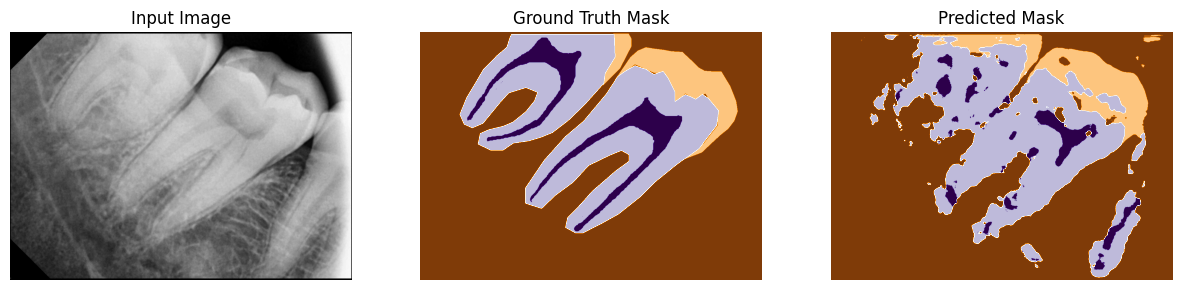

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(tf.squeeze(img[0]), cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Ground Truth Mask")
plt.imshow(gt_mask, cmap='PuOr')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(label_map, cmap='PuOr')
plt.axis('off')

plt.savefig('/kaggle/working.')
plt.show()
